In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\tejas\OneDrive\COVID19_Data_Analysis\data\country_wise_latest.csv")

In [7]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [8]:
df.shape


(187, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [10]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [11]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

In [14]:
df.rename(columns={
    'Country/Region':'Country',
    'New cases':'New_Cases',
    'New deaths':'New_Deaths',
    'New recovered':'New_Recovered'
}, inplace=True)

df.head()

,Country,Confirmed,Deaths,Recovered,Active,New_Cases,New_Deaths,New_Recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [15]:
top_cases = df.sort_values(by='Confirmed', ascending=False).head(10)

top_cases[['Country', 'Confirmed']]

,Country,Confirmed
173,US,4290259
23,Brazil,2442375
79,India,1480073
138,Russia,816680
154,South Africa,452529
111,Mexico,395489
132,Peru,389717
35,Chile,347923
177,United Kingdom,301708
81,Iran,293606


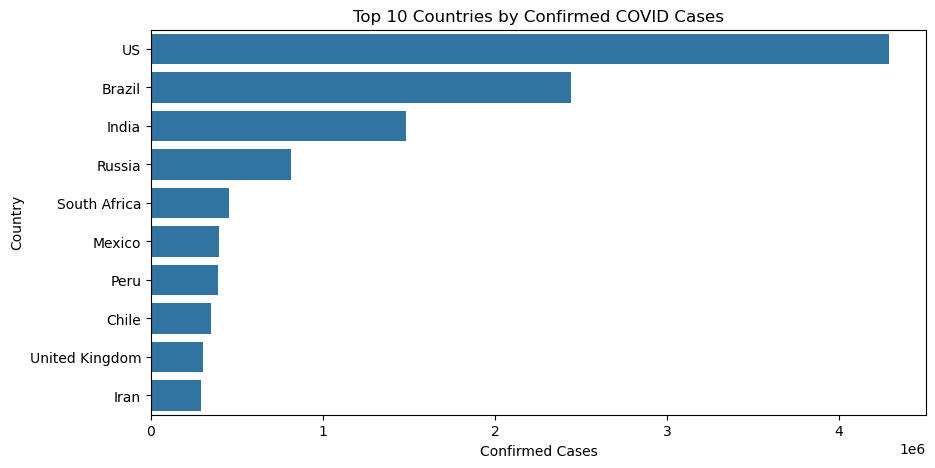

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_cases,
    x='Confirmed',
    y='Country'
)

plt.title("Top 10 Countries by Confirmed COVID Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")

plt.show()

In [17]:
top_deaths = df.sort_values(
    by='Deaths',
    ascending=False
).head(10)

top_deaths[['Country','Deaths']]

,Country,Deaths
173,US,148011
23,Brazil,87618
177,United Kingdom,45844
111,Mexico,44022
85,Italy,35112
79,India,33408
61,France,30212
157,Spain,28432
132,Peru,18418
81,Iran,15912


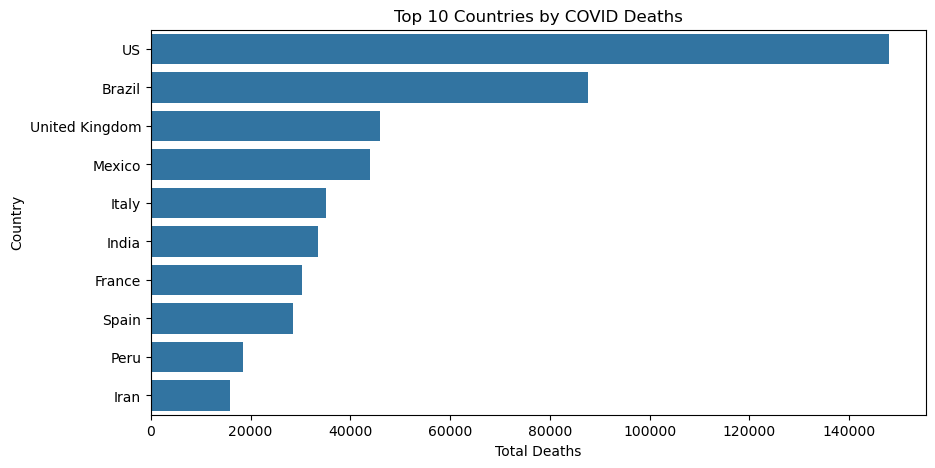

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_deaths,
    x='Deaths',
    y='Country'
)

plt.title("Top 10 Countries by COVID Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Country")

plt.show()

In [19]:
top_recovered = df.sort_values(
    by='Recovered',
    ascending=False
).head(10)

top_recovered[['Country','Recovered']]


,Country,Recovered
23,Brazil,1846641
173,US,1325804
79,India,951166
138,Russia,602249
35,Chile,319954
111,Mexico,303810
154,South Africa,274925
132,Peru,272547
81,Iran,255144
128,Pakistan,241026


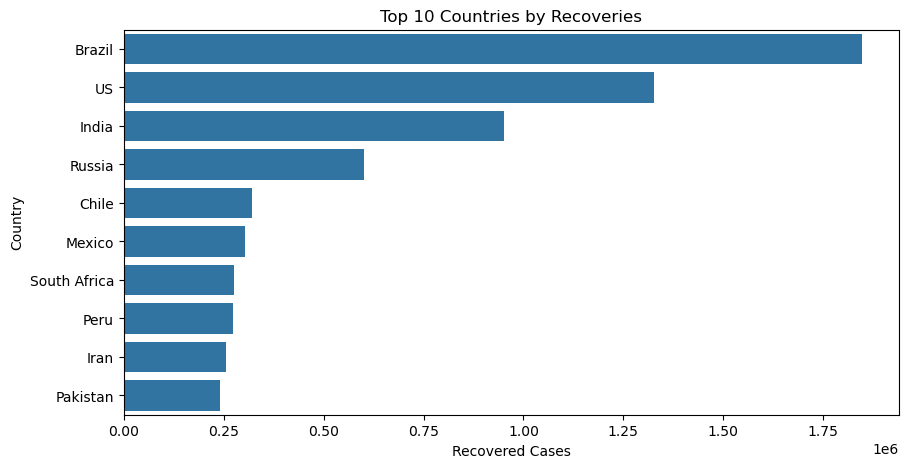

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_recovered,
    x='Recovered',
    y='Country'
)

plt.title("Top 10 Countries by Recoveries")
plt.xlabel("Recovered Cases")
plt.ylabel("Country")

plt.show()

In [21]:
df['Recovery_Rate'] = (df['Recovered'] / df['Confirmed']) * 100

df['Death_Rate'] = (df['Deaths'] / df['Confirmed']) * 100

df.head()

,Country,Confirmed,Deaths,Recovered,Active,New_Cases,New_Deaths,New_Recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Recovery_Rate,Death_Rate
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,69.486805,3.499435
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,56.250000,2.950820
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,67.339935,4.157581
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,88.533627,5.733186
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,25.473684,4.315789


In [22]:
top_recovery_rate = df.sort_values(
    by='Recovery_Rate',
    ascending=False
).head(10)

top_recovery_rate[['Country','Recovery_Rate']]

,Country,Recovery_Rate
75,Holy See,100.000000
69,Grenada,100.000000
49,Dominica,100.000000
48,Djibouti,98.379126
78,Iceland,98.327940
24,Brunei,97.872340
121,New Zealand,97.238279
136,Qatar,97.017254
105,Malaysia,96.597035
110,Mauritius,96.511628


In [23]:
region_cases = df.groupby('WHO Region')['Confirmed'].sum()

region_cases

WHO Region
Africa                    723207
Americas                 8839286
Eastern Mediterranean    1490744
Europe                   3299523
South-East Asia          1835297
Western Pacific           292428
Name: Confirmed, dtype: int64

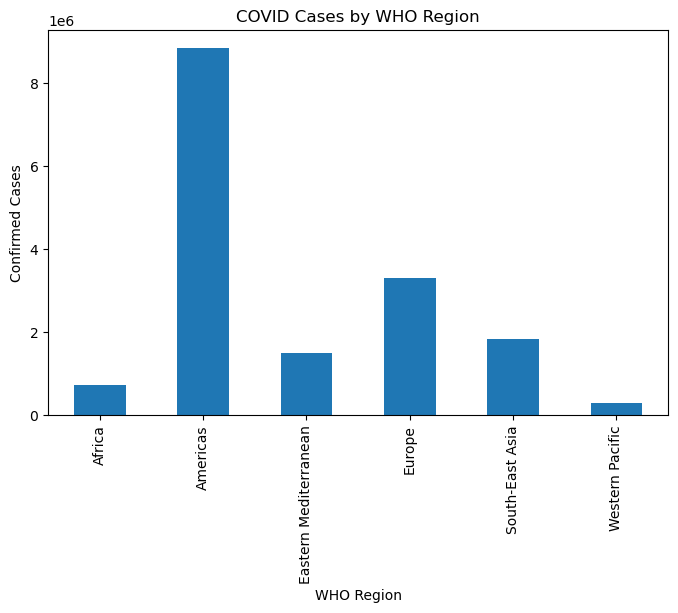

In [24]:
plt.figure(figsize=(8,5))

region_cases.plot(kind='bar')

plt.title("COVID Cases by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Confirmed Cases")

plt.show()

In [26]:
df.to_csv(
    r"C:\Users\tejas\OneDrive\COVID19_Data_Analysis\data\cleaned_covid_data.csv",
    index=False
)

print("Cleaned COVID dataset saved successfully")

Cleaned COVID dataset saved successfully


In [27]:
import os
os.getcwd()

'C:\\Users\\tejas'